In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error

In [2]:
df = pd.read_csv("data/city_hour.csv")

df.head()

,City,Datetime,PM2.5,PM10,NO,NO2,NOx,NH3,CO,SO2,O3,Benzene,Toluene,Xylene,AQI,AQI_Bucket
0,Ahmedabad,2015-01-01 01:00:00,NaN,NaN,1.00,40.01,36.37,NaN,1.00,122.07,NaN,0.0,0.0,0.0,NaN,NaN
1,Ahmedabad,2015-01-01 02:00:00,NaN,NaN,0.02,27.75,19.73,NaN,0.02,85.90,NaN,0.0,0.0,0.0,NaN,NaN
2,Ahmedabad,2015-01-01 03:00:00,NaN,NaN,0.08,19.32,11.08,NaN,0.08,52.83,NaN,0.0,0.0,0.0,NaN,NaN
3,Ahmedabad,2015-01-01 04:00:00,NaN,NaN,0.30,16.45,9.20,NaN,0.30,39.53,153.58,0.0,0.0,0.0,NaN,NaN
4,Ahmedabad,2015-01-01 05:00:00,NaN,NaN,0.12,14.90,7.85,NaN,0.12,32.63,NaN,0.0,0.0,0.0,NaN,NaN


In [3]:
# Convert Datetime
df['Datetime'] = pd.to_datetime(df['Datetime'])

# Filter city (recommended)
df = df[df['City'] == 'Kolkata']

# Sort and set index
df = df.sort_values('Datetime')
df.set_index('Datetime', inplace=True)

# Drop categorical columns (to avoid errors)
df = df.drop(columns=['City', 'AQI_Bucket'], errors='ignore')

# Fill missing values
df = df.fillna(method='ffill')

df.head()

C:\Users\User\AppData\Local\Temp\ipykernel_9984\368917949.py:15: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df = df.fillna(method='ffill')


,PM2.5,PM10,NO,NO2,NOx,NH3,CO,SO2,O3,Benzene,Toluene,Xylene,AQI
Datetime,,,,,,,,,,,,,
2018-04-10 10:00:00,34.82,54.45,NaN,51.45,NaN,NaN,1.13,NaN,NaN,NaN,NaN,NaN,NaN
2018-04-10 11:00:00,31.82,57.80,NaN,33.83,NaN,NaN,1.02,10.99,NaN,NaN,NaN,NaN,NaN
2018-04-10 12:00:00,29.61,51.04,NaN,16.60,NaN,NaN,0.94,8.16,NaN,NaN,NaN,NaN,NaN
2018-04-10 13:00:00,33.37,51.61,NaN,18.79,NaN,NaN,0.91,6.62,NaN,NaN,NaN,NaN,NaN
2018-04-10 14:00:00,36.71,58.00,NaN,23.19,NaN,NaN,0.91,6.80,NaN,NaN,NaN,NaN,NaN


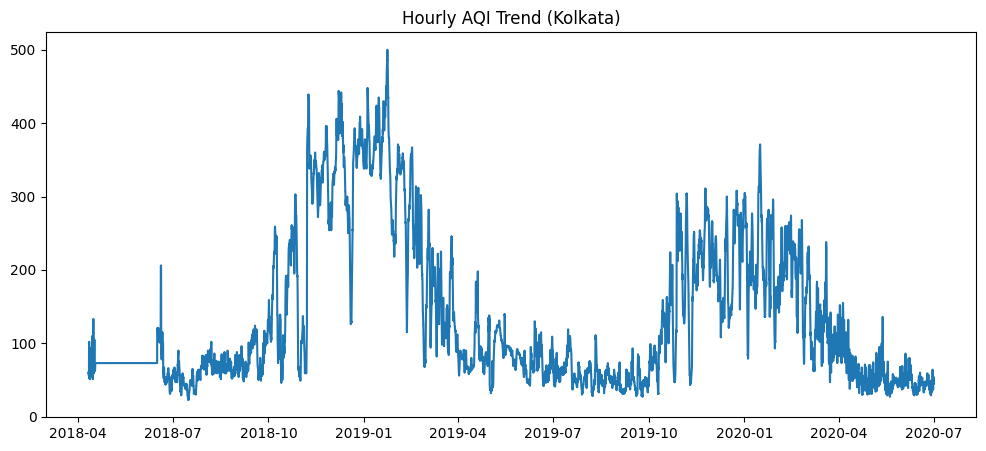

In [4]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,5))
plt.plot(df['AQI'])
plt.title("Hourly AQI Trend (Kolkata)")
plt.show()

In [5]:
# Time features (MORE POWERFUL NOW)
df['hour'] = df.index.hour
df['day'] = df.index.day
df['month'] = df.index.month
df['weekday'] = df.index.weekday

# Lag features (important for hourly)
df['lag_1'] = df['AQI'].shift(1)      # last hour
df['lag_24'] = df['AQI'].shift(24)    # same hour yesterday

# Rolling stats
df['rolling_mean_24'] = df['AQI'].rolling(24).mean()
df['rolling_std_24'] = df['AQI'].rolling(24).std()

df = df.dropna()

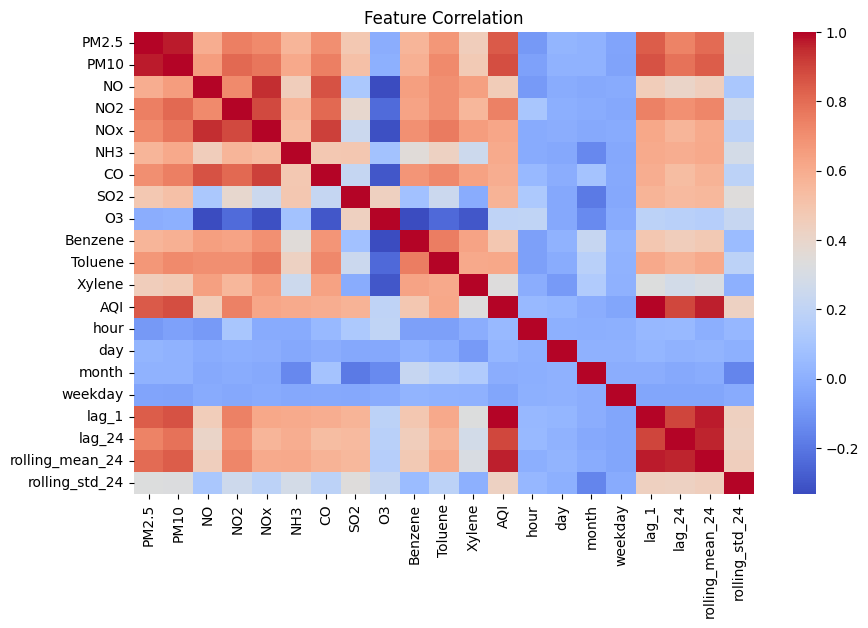

In [6]:
import seaborn as sns

plt.figure(figsize=(10,6))

numeric_df = df.select_dtypes(include=['number'])
sns.heatmap(numeric_df.corr(), cmap='coolwarm')

plt.title("Feature Correlation")
plt.show()

In [7]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error

# Only numeric data
df_model = df.select_dtypes(include=['number'])

X = df_model.drop(columns=['AQI'])
y = df_model['AQI']

# Time series split
split = int(len(df_model) * 0.8)

X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]

model = RandomForestRegressor(n_estimators=100)
model.fit(X_train, y_train)

preds = model.predict(X_test)

print("MAE:", mean_absolute_error(y_test, preds))

MAE: 1.7270730425643719


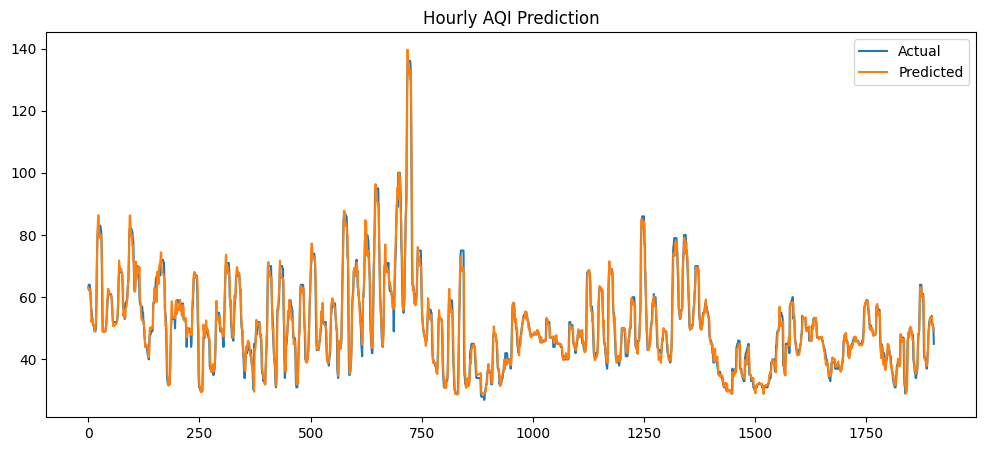

In [8]:
plt.figure(figsize=(12,5))
plt.plot(y_test.values, label='Actual')
plt.plot(preds, label='Predicted')
plt.legend()
plt.title("Hourly AQI Prediction")
plt.show()

In [9]:
import numpy as np

mean = df['AQI'].mean()
std = df['AQI'].std()

df['z_score'] = (df['AQI'] - mean) / std
df['anomaly'] = np.where(abs(df['z_score']) > 3, 1, 0)

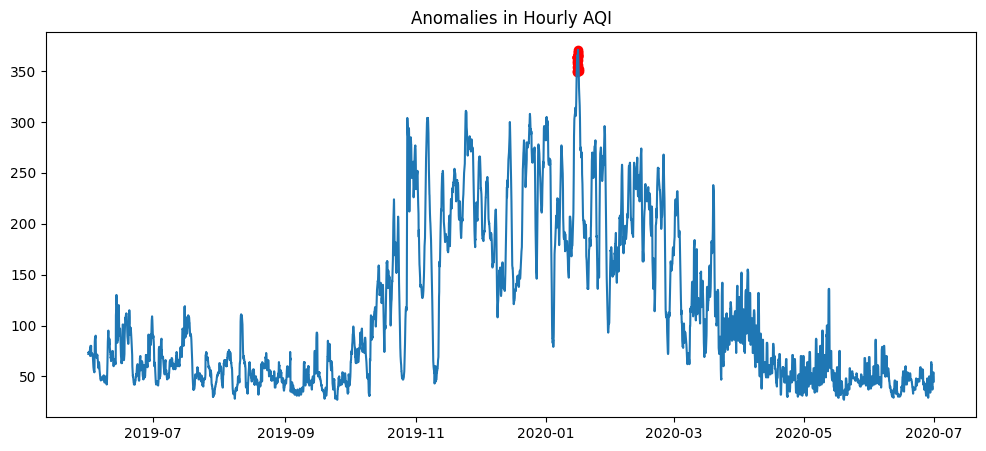

In [10]:
plt.figure(figsize=(12,5))
plt.plot(df['AQI'], label='AQI')

anomalies = df[df['anomaly'] == 1]
plt.scatter(anomalies.index, anomalies['AQI'], color='red')

plt.title("Anomalies in Hourly AQI")
plt.show()